In [1]:
# Standard Libraries
import math
import os
import pickle
import random
import time
from datetime import datetime

# Data Manipulation and Visualization
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')  # For saving figures
from IPython.display import clear_output
from tqdm import tqdm

# PyTorch Libraries and Tools
import torch
import torch.nn as nn
from torch.autograd import Variable
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter

# Custom Modules (QGAN2, Discriminator, MINE)
from modules import QGAN, Discriminator, MINE
from modules.utils import convert_ipynb_to_html  # For saving HTML files
import importlib  # For reloading modules
importlib.reload(QGAN)
importlib.reload(Discriminator)
importlib.reload(MINE)

# quantum computing
import pennylane as qml

import argparse
import json

In [2]:

# 전역 변수 선언
train_type = "InfoQGAN"
use_mine = True if train_type == "InfoQGAN" else False
n_qubits = 7
n_layers = 20
BATCH_SIZE = 16
TARGETS_STR = ""
TARGETS = [1, 2]
G_lr = 0.005
M_lr = 0.0001
D_lr = 0.001
smooth = 0.0
SEED = 1
epoch_num = 300
gamma = 0.8
COEFF = 0.05
code_qubits = 3
train_size = 1000
ARGS = None

In [165]:
if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Training parameters")
    parser.add_argument("--model_type", choices=['InfoQGAN', 'QGAN'], required=True, help="Model type to use: InfoQGAN or QGAN")
    parser.add_argument("--TARGETS", type=str, required=True, help="Target digits")
    parser.add_argument("--n_qubits", type=int, required=True, help="Number of qubits")
    parser.add_argument("--n_layers", type=int, default=10, help="Number of layers for quantum circuits")
    parser.add_argument("--G_lr", type=float, default=0.005, help="Learning rate for generator")
    parser.add_argument("--M_lr", type=float, default=0.0001, help="Learning rate for mine")
    parser.add_argument("--D_lr", type=float, default=0.001, help="Learning rate for discriminator")
    parser.add_argument("--coeff", type=float, default=0.05, help="Coefficient value used for InfoQGAN (not used for QGAN)")
    parser.add_argument("--seed", type=float, default=1.5, help="Seed value range (-seed, seeed)")
    parser.add_argument("--smooth", type=float, default=0.0, help="Discriminator label smoothing (efficient for QGAN)")
    parser.add_argument("--epochs", type=int, required=True, help="Number of epochs")
    parser.add_argument("--gamma", type=float, default=0.8, help="Learning rate scheduler gamma (step = 30 epochs)")
    parser.add_argument("--code", type=int, default=3, help="Number of code qubits")
    parser.add_argument("--train_size", type=int, default=2000, help="Train dataset size")

    args = parser.parse_args()
    ARGS = args

    train_type = args.model_type
    use_mine = (train_type == 'InfoQGAN')
    n_qubits = args.n_qubits
    n_layers = args.n_layers
    TARGETS = list(map(int, args.TARGETS))
    TARGETS_STR = args.TARGETS

    G_lr = args.G_lr
    M_lr = args.M_lr
    D_lr = args.D_lr
    COEFF = args.coeff
    smooth = args.smooth
    SEED = args.seed
    epoch_num = args.epochs
    gamma = args.gamma
    train_size = args.train_size
    code_qubits = args.code

    print(f"Use Mine: {use_mine}")
    print(f"n_qubits = {n_qubits}, n_layers = {n_layers}, total params = {n_qubits * n_layers}")
    print(f"TARGETS: {TARGETS}")
    # assert that TARGETS are in DIGITS
    
    print(f"Generator Learning Rate: {G_lr}")
    print(f"Mine Learning Rate: {M_lr}")
    print(f"Discriminator Learning Rate: {D_lr}")
    if use_mine:
        print(f"InfoQGAN coefficient: {COEFF}")
    print(f"Smooth: {smooth}")
    print(f"Seed Range: {-SEED} ~ {SEED}")
    print(f"Epochs: {epoch_num}")
    print(f"Gamma: {gamma}")
    print(f"Code Qubits: {code_qubits}")
    print(f"Number of Images per Class: {train_size}")

usage: ipykernel_launcher.py [-h] --model_type {InfoQGAN,QGAN} --TARGETS
                             TARGETS --n_qubits N_QUBITS [--n_layers N_LAYERS]
                             [--G_lr G_LR] [--M_lr M_LR] [--D_lr D_LR]
                             [--coeff COEFF] [--seed SEED] [--smooth SMOOTH]
                             --epochs EPOCHS [--gamma GAMMA] [--code CODE]
                             [--train_size TRAIN_SIZE]
ipykernel_launcher.py: error: the following arguments are required: --model_type, --TARGETS, --n_qubits, --epochs


SystemExit: 2

c:\Users\minkyu\anaconda3\envs\quantum\lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
img_size = int(2 ** (n_qubits/2))

# 데이터 변환 정의
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_size, img_size)),  # img_size * img_size 크기로 압축
])

# MNIST 데이터 로드
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# TARGET_DIGITS 에 해당하는 데이터를 각각 train_size / len(TARGET_DIGITS) 개씩 추출
train_data_dict = {i: [data[0][0] for data in train_data if data[1] == i] for i in TARGETS}
train_data_dict = {i: train_data_dict[i][:train_size // len(TARGETS)] for i in TARGETS}
train_data = np.array([data/data.max() for i in TARGETS for data in train_data_dict[i]]) # 최대값 1로 정규화

print("train_data shape =", train_data.shape)

train_data shape = (1000, 11, 11)


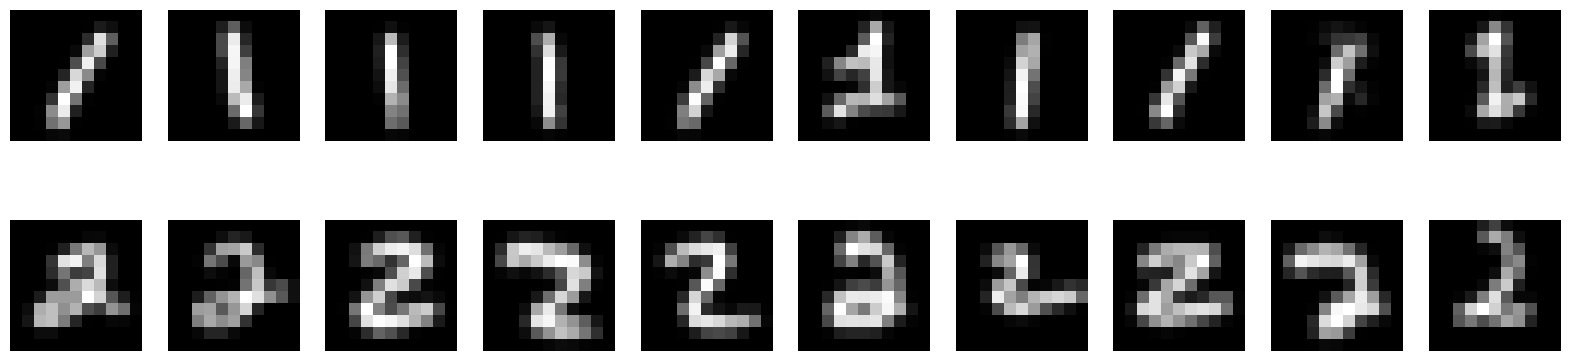

In [4]:
# plot len(TARGETS) * 10 images
fig, axs = plt.subplots(len(TARGETS), 10, figsize=(20, 1+2*len(TARGETS)))
for i, target in enumerate(TARGETS):
    for j in range(10):
        axs[i, j].imshow(train_data_dict[target][j], cmap='gray')
        axs[i, j].axis('off')

In [5]:
ml_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("학습에 사용할 device =", ml_device)
qml_device = qml.device("default.qubit", wires=n_qubits)

generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi, np.pi, (n_layers, n_qubits, 1))), requires_grad=True)
generator = QGAN.QGAN2(n_qubits, n_qubits, n_layers, generator_initial_params, qml_device)
discriminator = Discriminator.LinearDiscriminator(input_dim = img_size**2, hidden_size=100)
mine = MINE.LinearMine(code_dim=code_qubits, output_dim=img_size**2, size=50)
print("n_qubits = {} n_layers = {} 총 파라미터 수 = {}".format(n_qubits, n_layers, generator_initial_params.numel()))

G_opt = torch.optim.Adam([generator.params], lr=G_lr)
D_opt = torch.optim.Adam(discriminator.parameters(), lr=D_lr)
M_opt = torch.optim.Adam(mine.parameters(), lr=M_lr)

G_scheduler = torch.optim.lr_scheduler.StepLR(G_opt, step_size=30, gamma=gamma)
D_scheduler = torch.optim.lr_scheduler.StepLR(D_opt, step_size=30, gamma=gamma)
M_scheduler = torch.optim.lr_scheduler.StepLR(M_opt, step_size=30, gamma=gamma)

학습에 사용할 device = cpu
n_qubits = 7 n_layers = 20 총 파라미터 수 = 140


In [6]:
def generator_postprocessing(generator_output):
    # generator_output: (BATCH_SIZE, img_size**2), 값: [0,1] 범위
    # 평균 이하인 값만 제곱해서 값을 더 작게 만듦
    mask = generator_output < generator_output.mean(dim=1, keepdim=True)
    ratio = generator_output / generator_output.mean(dim=1, keepdim=True)
    adjusted_output = generator_output.clone()  # 기존 텐서를 복사
    adjusted_output[mask] = (((ratio) ** 2) * generator_output.mean(dim=1, keepdim=True))[mask]
    
    # max 정규화로 [0,1] 맞추기
    normalized_output = adjusted_output / adjusted_output.max(dim=1, keepdim=True).values
    
    return normalized_output


# 학습에 사용할 train_step과 disc_cost_fn 정의 
def generator_train_step(generator_seed, use_mine = False):
    '''
    params (torch.Tensor(레이어,큐빗,3)): a parameter
    generator_input (torch.Tensor(BATCH_SIZE, seed_dim)): 생성기 입력 seed (code+noise).
    '''
    code_input = generator_seed[:, :code_qubits] # 입력중에서 code만 뽑는다. (BATCH_SIZE, code_qubits)
    generator_output = generator.forward(generator_seed) # 출력을 뽑아낸다 (BATCH_SIZE, 2**output_qubits)

    generator_output = generator_output.to(torch.float32) # (BATCH_SIZE,  2**output_qubits)
    generator_output = generator_output[:, :img_size**2] # (BATCH_SIZE, img_size**2)
    generator_output = generator_postprocessing(generator_output) # 후처리를 통해 이미지 조정
    disc_output = discriminator(generator_output) # 밑에 코드에서 정의됨
    gan_loss = torch.log(1-disc_output).mean()
    
    if use_mine:
        pred_xy = mine(code_input, generator_output)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, generator_output)
        mi = torch.mean(pred_xy) - torch.log(torch.mean(torch.exp(pred_x_y)))
        gan_loss -= COEFF * mi

    return generator_output, gan_loss

disc_loss_fn = nn.BCELoss()
def disc_cost_fn(real_input, fake_input):
    batch_num = real_input.shape[0]

    disc_real = discriminator(real_input)
    disc_fake = discriminator(fake_input)

    real_label = torch.ones((batch_num, 1)).to(ml_device)
    fake_label = torch.zeros((batch_num, 1)).to(ml_device)
    
    if smooth > 0.00001:
        real_label = real_label - smooth*torch.rand(real_label.shape).to(ml_device)
    
    loss = 0.5 * (disc_loss_fn(disc_real, real_label) + disc_loss_fn(disc_fake, fake_label))
    
    return loss

In [170]:
def visualize_output_simple(gen_outputs, gen_codes, epoch, writer, image_file_path):
    gen_outputs = torch.tensor(gen_outputs[:100], dtype=torch.float32)
    
    # 1. 첫 번째 플롯: 10*10 그리드에 생성된 이미지 시각화 (랜덤 순서)
    fig, axs = plt.subplots(10, 10, figsize=(10, 10), dpi=80)
    for i in range(10):
        for j in range(10):
            axs[i, j].imshow(gen_outputs[i*10+j].reshape(img_size, img_size).detach().numpy(), cmap='gray')
            axs[i, j].axis('off')
    plt.suptitle(f"TARGETS={TARGETS_STR} nq={n_qubits} nl={n_layers} epoch={epoch}")
    
    writer.add_figure(f'2D Distribution', fig, epoch)
    fig.savefig(f'{image_file_path}/generated_epoch{epoch:03d}.png')
    plt.close(fig)

    # 2. code_qubits 값별로 정렬하여 10*10 이미지 배치 생성 및 저장
    code_qubits = gen_codes.shape[1]
    front_100_codes = gen_codes[:100]  # gen_codes에서 앞 100개의 코드만 사용
    for q in range(code_qubits):
        # 각 code_qubit 값으로 정렬
        sorted_indices = front_100_codes[:, q].argsort()
        sorted_output = gen_outputs[sorted_indices]  # 정렬된 상위 100개 사용

        fig, axs = plt.subplots(10, 10, figsize=(10, 10), dpi=80)
        for i in range(10):
            for j in range(10):
                axs[i, j].imshow(sorted_output[i*10+j].reshape(img_size, img_size).detach().numpy(), cmap='gray')
                axs[i, j].axis('off')
        plt.suptitle(f"TARGETS={TARGETS_STR} nq={n_qubits} nl={n_layers} code_qubit={q} epoch={epoch}")
        writer.add_figure(f'Sorted by Code Qubit {q}', fig, epoch) # TensorBoard에 기록
        fig.savefig(f'{image_file_path}/sorted_{q}_epoch{epoch:03d}.png') # 이미지 파일로 저장
        plt.close(fig)

In [171]:

current_time = datetime.now().strftime("%b%d_%H_%M_%S")  # "Aug13_14_12_30" 형식
save_dir = f"./runs/MNIST_{TARGETS_STR}_{train_type}_nq{n_qubits}_nl{n_layers}_{current_time}"
scalar_save_path = os.path.join(save_dir, f"MNIST_{TARGETS_STR}_{train_type}_nq{n_qubits}_nl{n_layers}_{current_time}.csv")
image_save_dir = os.path.join(save_dir, "images")
param_save_dir = os.path.join(save_dir, "params")
os.makedirs(image_save_dir, exist_ok=True)
os.makedirs(param_save_dir, exist_ok=True)

# ======================파이썬 코드를 html 로 만듦=======================
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter

def convert_py_to_html(py_file_path, html_file_path):
    """Converts a Python script to a syntax-highlighted HTML file."""
    with open(py_file_path, 'r', encoding='utf-8') as f:
        code = f.read()

    html_code = highlight(code, PythonLexer(), HtmlFormatter(full=True, linenos=True))
    
    with open(html_file_path, 'w', encoding='utf-8') as f:
        f.write(html_code)

    print(f"Converted {py_file_path} to {html_file_path} with syntax highlighting.")
convert_py_to_html('new_mnist.py', os.path.join(save_dir, 'new_mnist.html'))
# ==========================================================

# save ARGS in save_dir/args.txt
if ARGS is not None:
    with open(os.path.join(save_dir, 'args.txt'), 'w') as f:
        json.dump(ARGS.__dict__, f, indent=4)
        print(f"args 객체가 {save_dir}/args.txt 파일에 저장되었습니다.")

# CSV 파일 초기화 (헤더 작성)
df = pd.DataFrame(columns=['epoch', 'D_loss', 'G_loss', 'MI', 'FD', 'time'])

# TensorBoard SummaryWriter 초기화
writer = SummaryWriter(log_dir=save_dir)

start_time = time.time()

def categorical_distribution(S, E, T, size): # S~E를 T개로 내분하는 categorical distribution.
    if T == 1:
        categories = [(S+E)/2]
    else:
        categories = np.linspace(S, E, T)
    return torch.tensor(np.random.choice(categories, size))

from torch.utils.data import DataLoader, TensorDataset

train_tensor = torch.tensor(train_data, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    drop_last=True  # 마지막 배치 크기가 작으면 무시
)

Converted new_mnist.py to ./runs/MNIST__InfoQGAN_nq7_nl20_Jan07_23_33_14\new_mnist.html with syntax highlighting.


In [173]:
for epoch in range(1, epoch_num+1):
    G_loss_sum = 0.0
    D_loss_sum = 0.0
    mi_sum = 0.0
    batch_num = train_size // BATCH_SIZE

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epoch_num}", unit="batch")

    # 그림 그릴때 필요하다
    gen_outputs = [] # (데이터수, 2) 생성한 모든 점의 좌표들
    gen_codes = [] # (데이터수, 2) 점 찍는데 들어간 code들

    for batch_idx, (batch,) in enumerate(pbar):  # batch unpack
        # # train generator
        generator_seed = torch.empty((BATCH_SIZE, n_qubits)).uniform_(-SEED, SEED)
        generator_output, generator_loss = generator_train_step(generator_seed, use_mine=use_mine)
        G_opt.zero_grad()
        generator_loss.requires_grad_(True)
        generator_loss.backward()
        G_opt.step()
        
        # train discriminator
        fake_input = generator_output.detach().to(torch.float32)
        disc_loss = disc_cost_fn(batch, fake_input)
        D_opt.zero_grad()
        disc_loss.requires_grad_(True)
        disc_loss.backward()
        D_opt.step()

        # train mine
        code_input = generator_seed[:, -code_qubits:] # (BATCH_SIZE, code_qubits) 코드만 추출
        pred_xy = mine(code_input, fake_input)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, fake_input)
        mi = -torch.mean(pred_xy) + torch.log(torch.mean(torch.exp(pred_x_y)))
        M_opt.zero_grad()
        mi.requires_grad_(True)
        mi.backward()
        M_opt.step()

        D_loss_sum += disc_loss.item()
        G_loss_sum += generator_loss.item()
        mi_sum -= mi.item() # (-1)곱해져 있어서 빼야함.

        gen_outputs.append(fake_input.detach().numpy())
        gen_codes.append(code_input.detach().numpy())

        pbar.set_postfix({'G_loss': G_loss_sum/(batch_idx+1), 'D_loss': D_loss_sum/(batch_idx+1), 'MI': mi_sum/(batch_idx+1)})

    G_scheduler.step()
    D_scheduler.step()
    M_scheduler.step()
    
    gen_outputs = np.concatenate(gen_outputs, axis=0) # (train_num, 2**output_qubits)
    gen_codes = np.concatenate(gen_codes, axis=0) # (train_num, code_qubits)

    D_loss, G_loss, mi = D_loss_sum/batch_num, G_loss_sum/batch_num, mi_sum/batch_num

    writer.add_scalar('Loss/d_loss', D_loss, epoch)
    writer.add_scalar('Loss/g_loss', G_loss, epoch)
    writer.add_scalar('Metrics/mi', mi, epoch)

    # 스칼라 값 CSV로 덮어쓰기 저장
    file_exists = os.path.isfile(scalar_save_path)
    new_data = pd.DataFrame({
        'epoch': [epoch],
        'D_loss': [D_loss],
        'G_loss': [G_loss],
        'MI': [mi],
        'time': [int((time.time() - start_time)*1000)]
    })

    new_data.to_csv(scalar_save_path, mode='a', header=not file_exists)
    
    visualize_output_simple(gen_outputs, gen_codes, epoch, writer, image_save_dir) # save fig here

    # 각 epoch마다 generator 파라미터 저장
    torch.save(generator.params, f'{param_save_dir}/generator_params_epoch{epoch}.pth')
    
    print("epoch: {}, D_loss: {}, G_loss: {}, MI = {}".format(epoch, D_loss, G_loss, mi))

    # Epoch 끝에서 필요 없는 변수를 삭제
    del generator_output, fake_input, batch
    torch.cuda.empty_cache()


Epoch 1/300: 100%|██████████| 8/8 [00:17<00:00,  2.23s/batch, G_loss=-0.635, D_loss=0.595, MI=-0.00586]


epoch: 1, D_loss: 0.5945175811648369, G_loss: -0.635252445936203, MI = -0.005856736999703571


Epoch 2/300: 100%|██████████| 8/8 [00:17<00:00,  2.19s/batch, G_loss=-0.501, D_loss=0.392, MI=-0.00812]


epoch: 2, D_loss: 0.39209677651524544, G_loss: -0.501490093767643, MI = -0.008118290221318603


Epoch 3/300: 100%|██████████| 8/8 [00:18<00:00,  2.30s/batch, G_loss=-0.23, D_loss=0.145, MI=-0.00485] 


...

epoch: 298, D_loss: 6.110337835707469e-07, G_loss: -0.009452546364627779, MI = 0.0743461879901588


Epoch 299/300: 100%|██████████| 8/8 [00:17<00:00,  2.23s/batch, G_loss=-0.0077, D_loss=6.32e-7, MI=0.0662] 


epoch: 299, D_loss: 6.320100389700656e-07, G_loss: -0.00769754609791562, MI = 0.06619942490942776


Epoch 300/300: 100%|██████████| 8/8 [00:17<00:00,  2.22s/batch, G_loss=-0.00781, D_loss=5.71e-7, MI=0.0634]


epoch: 300, D_loss: 5.713785729000165e-07, G_loss: -0.007813806645572186, MI = 0.06344497506506741


In [13]:
def generator_postprocessing(generator_output):
    # generator_output: (BATCH_SIZE, img_size**2), 값: [0,1] 범위
    # 평균 이하인 값만 제곱해서 값을 더 작게 만듦
    ratio = generator_output / (1 / (img_size ** 2))
    adjusted_output = (ratio ** 2) * (1 / (img_size ** 2))
    
    # max 정규화로 [0,1] 맞추기
    normalized_output = adjusted_output / adjusted_output.max(dim=1, keepdim=True).values
    
    return normalized_output


In [9]:
generator_seed = torch.empty((100, n_qubits)).uniform_(-SEED, SEED)
generator_output = generator.forward(generator_seed)[:, :img_size**2] # (25, img_size*img_size)
generator_output = generator_postprocessing(generator_output)

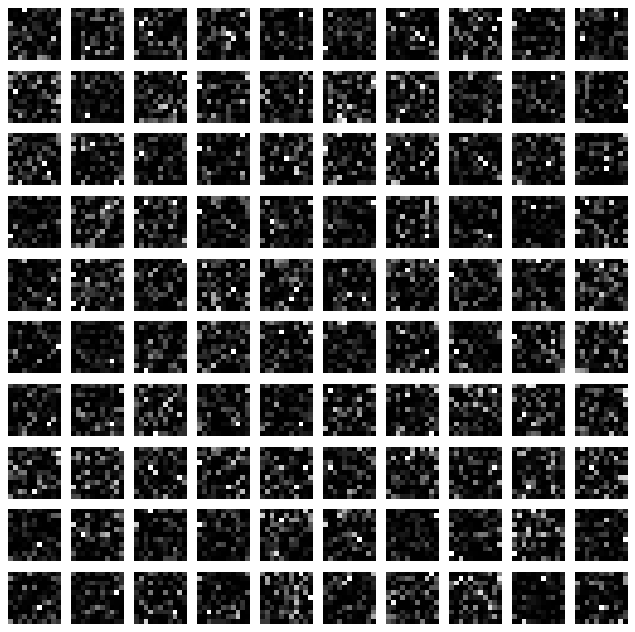

In [129]:
fig, axs = plt.subplots(10, 10, figsize=(10, 10), dpi=80)
for i in range(10):
    for j in range(10):
        axs[i, j].imshow(generator_output[i*10+j].reshape(img_size, img_size).detach().numpy(), cmap='gray')
        axs[i, j].axis('off')

tensor([0.2909], dtype=torch.float64, grad_fn=<SelectBackward0>)


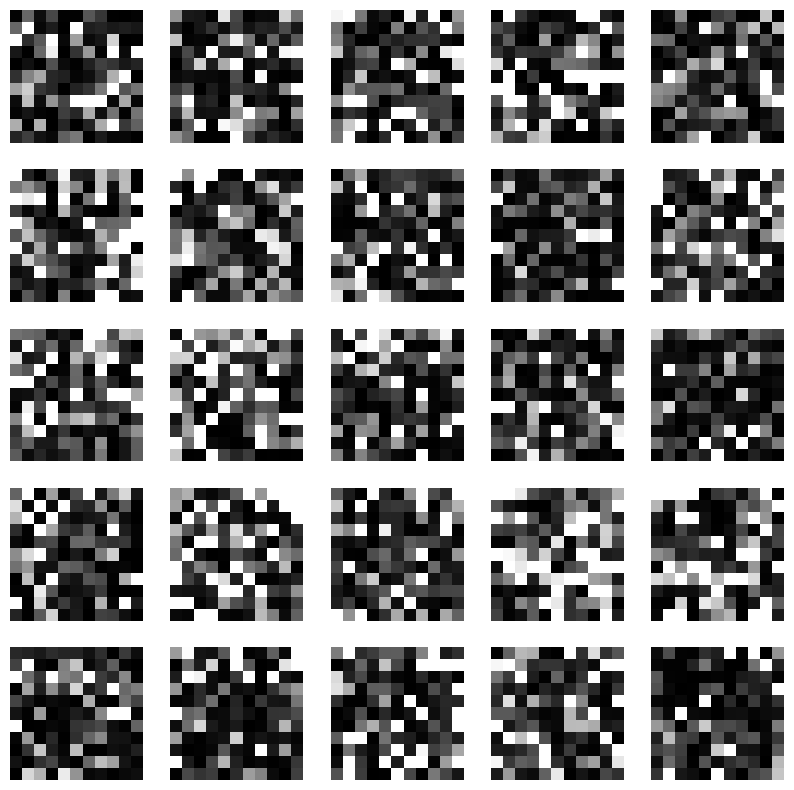

In [14]:
# visualize 25 generated images
generator_output = generator.forward(generator_seed)[:, :img_size**2] # (25, img_size*img_size)
generator_output = generator_output / generator_output.max(dim=1, keepdim=True).values
generator_output = (generator_output * 3).clip(0, 1)
print(generator_output.mean(dim=1, keepdim=True)[0])
fig, axs = plt.subplots(5, 5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axs[i, j].imshow(generator_output[i*5+j].reshape((img_size, img_size)).detach().numpy(), cmap='gray')
        axs[i, j].axis('off')

tensor([0.1049], dtype=torch.float64, grad_fn=<SelectBackward0>)


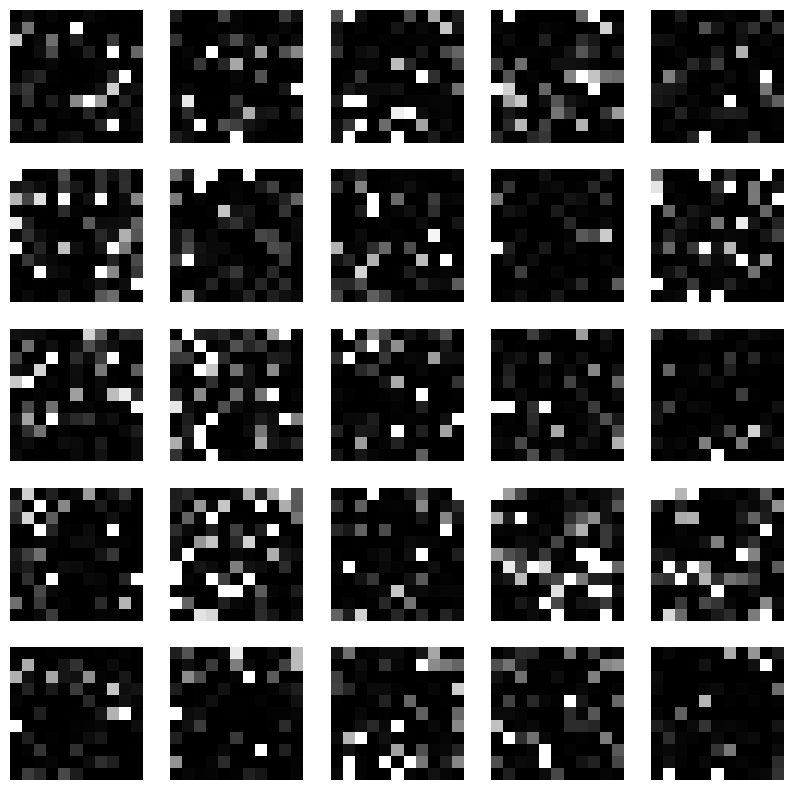

In [15]:
# visualize 25 generated images
generator_output = generator.forward(generator_seed)[:, :img_size**2] # (25, img_size*img_size)
generator_output = generator_postprocessing(generator_output)
generator_output = (generator_output * 3).clip(0, 1)
print(generator_output.mean(dim=1, keepdim=True)[0])
fig, axs = plt.subplots(5, 5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axs[i, j].imshow(generator_output[i*5+j].reshape((img_size, img_size)).detach().numpy(), cmap='gray')
        axs[i, j].axis('off')

In [59]:
mask = generator_output < generator_output.mean(dim=1, keepdim=True)

In [66]:
ratio = generator_output / generator_output.mean(dim=1, keepdim=True)

In [74]:
generator_output[mask] = (ratio ** 2 * generator_output.mean(dim=1, keepdim=True))[mask]

In [85]:
generator_output.max(dim=1).values

tensor([0.0433, 0.0577, 0.0612, 0.0688, 0.0738, 0.0828, 0.0603, 0.0550, 0.0582,
        0.0712, 0.0479, 0.0530, 0.0752, 0.0366, 0.0529, 0.0546, 0.0540, 0.0543,
        0.0538, 0.0571, 0.0714, 0.0615, 0.0649, 0.0654, 0.0859],
       dtype=torch.float64, grad_fn=<MaxBackward0>)

In [12]:
generator_output < (1 / (img_size**2))

tensor([[False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False,  True, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False,  True, False,  ..., False, False, False],
        [False, False, False,  ...,  True, False, False]])